# Übung 1

**Gruppenname:**

*TKKR*

Gehen Sie wie folgt vor:

1. Bitte benennen Sie jetzt dieses Jupyter Notebook um (z.B. über `File -> Rename`):

   Namensschema: `Gruppenname-X`. Ersetzen Sie "X" mit der oben angegebenen Nummer der Übung.

   - Beispiel 1: Team REZA bearbeitet Übung 2. Das Notebook heißt: REZA-2.
   - Beispiel 2: Sie sind keinem Team zugeordnet (nicht empfehlenswert) und bearbeiten Übung 2: Ihr Notebook heißt: Nachname-2.

2. Tragen Sie Ihren Gruppennamen auch ganz oben bei "Name Ihrer Gruppe" ein.

3. Bearbeiten Sie dann dieses Notebook. Vergessen Sie dabei nicht, das Jupyter Notebook regelmäßig zu speichern (z.B. über `Strg + S` oder über `File -> Save and Checkpoint`).

## 1.1 Zentrale Lernprobleme im Machine Learning


In dieser kurzen Übung möchte ich Ihren Blick für die verschiedenen Lernproblemtypen im Machine Learning schärfen. Wenn Sie mit Daten zu tun haben, dann werden Sie oft Ideen generieren wollen, was Sie mit den Daten eigentlich machen können. Ihre Daten bestimmen, welche Methoden und welche Lernproblemtypen im Machine Learning anwendbar sind.

* Betrachten Sie kurz noch einmal die folgende Folie aus der Vorlesung. 
* Als kurze Erinnerung zur Vorlesung: Unsupervised Learning wird typischerweise für Aufgaben wie Clustering (= Einteilen von Objekten in verschiedene Gruppen) oder Dimensionsreduktion eingesetzt.
* Bearbeiten Sie dann die unter der Folie stehenden Fragen.

<img src="https://data.bialonski.de/ml/exercise-1.png" style="border:1px solid black">

Sie finden unten eine Liste von Aufgaben und Daten.

* Im Falle von Aufgaben: In welche der drei auf der Folie genannten Lernproblemklassen (Supervised, Unsupervised, Reinforcement Learning) fallen diese Aufgaben? Bei Ihren Überlegungen kann es hilfreich sein, sich vorzustellen, welche Daten bei den Aufgaben vorliegen könnten. 

* Im Falle von Daten: Generieren Sie Ideen und Fragestellungen, die Sie anhand der Daten untersuchen könnten. In welche Lernproblemklassen fallen Ihre Ideen?

Mehrfachantworten können möglich sein. Begründen Sie ganz kurz Ihre Antwort (1-3 Sätze maximum). 

1\. Automatische Buchempfehlung für Kunden eines Onlinebuchhändlers.

Antwort: Anfänglich Unsupervised, um Kaufverhalten zu clustern und später Reinforced, um weiter zu lernen, wenn das vorgeschlagene Buch gekauft wurde

2\. Vorhersage des Kreditlimits von Bankkunden.

Antwort: Supervised, da es ganz klare entscheidungsfunktionen gibt

3\. Spielen des Strategiespiels Tic-Tac-Toe.

Antwort: Reinforced, da eine Strategie gefunden werden muss, um die Belohnung (Gewonnen) zu maximieren

4\. Eine Datenbank mit Songs (Audiodaten).

Antwort: Clustering durch Unsupervised

5\. Eine Datenbank mit Songs (Audiodaten) sowie Songtitel und Künstler.

Antwort: Clustering durch Unsupervised

6\. 32 ausgefüllte Fragebögen von Teilnehmern einer Machine Learning Vorlesung aus dem Jahr 2018 (siehe Abbildung unten). ;-) 

<img src="https://data.bialonski.de/ml/background-knowledge-probe.jpg" width="60%" style="border:1px solid black">

Antwort: Anfänglich Supervised, da es ein klares Richtig und Falsch gibt und später das Finetuning über Reinforced

# 1.2 Schwertliliendatensatz (iris dataset)
In der folgenden Code Zelle habe ich Ihnen einen Befehl aus der Python Bibliothek *scikit-learn* aufgeschrieben, mit dessen Hilfe Sie den Iris-Datensatz importieren. Der Iris-Datensatz enthält Eigenschaften (*features*) dreier Schwertlilienarten sowie Informationen, zu welcher Schwertlilienart (*target*) jeweils ein Satz von *Features* gehört. Lassen sich die drei Schwertlilienarten anhand der erfassten Features unterscheiden? Dies wollen wir uns einmal anschauen.

Wie bei jedem Machine Learning Projekt beginnen wir mit einer Untersuchung des Datensatzes. Untersuchen Sie den Datensatz, der sich im *data* Objekt befindet und beantworten Sie die folgenden Fragen.


In [1]:
# Wir importieren zunächst numpy und Teile von Matplotlib. Diese werden Sie noch später brauchen.
import numpy as np
from matplotlib import pyplot as plt

# Und hier importieren wir den Schwertlilien-Datensatz.
from sklearn.datasets import load_iris

data = load_iris()
print(data.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


(1) Welche und wie viele Eigenschaften (*features*) enthält der Datensatz?

In [2]:
print(f"Der Datensatz enthält {len(data.feature_names)} features und zwar '{', '.join(data.feature_names)}'")

Der Datensatz enthält 4 features und zwar 'sepal length (cm), sepal width (cm), petal length (cm), petal width (cm)'


(2) Wie werden die drei Schwertlilienarten (*labels*) im Datensatz kodiert?

In [3]:
print(f"Die drei Arten {', '.join(data.target_names)} werden als die drei Ziffern {', '.join(set(map((lambda i: f"{i}"), data.target.tolist())))} beschrieben.")

Die drei Arten setosa, versicolor, virginica werden als die drei Ziffern 0, 2, 1 beschrieben.


(3) Wie viele Schwertlilien wurden vermessen? (Sie können z.B. die `.shape` Methode nutzen, um die Dimensionen von numpy-arrays zu ermitteln.)

In [4]:
print(f"Es wurden {data.data.shape[0]} Schwertlilien vermessen")

Es wurden 150 Schwertlilien vermessen


(4) Gewinnen Sie einen ersten Eindruck über die Verteilung der einzelnen Features: 
  * Erzeugen Sie für jedes Feature jeweils ein Histogram über alle Schwertlilien hinweg. (Sie können den `hist` Befehl in der Matplotlib dafür verwenden ([Dokumentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html))).
  * Fallen Ihnen Unterschiede zwischen den Histogrammen auf?

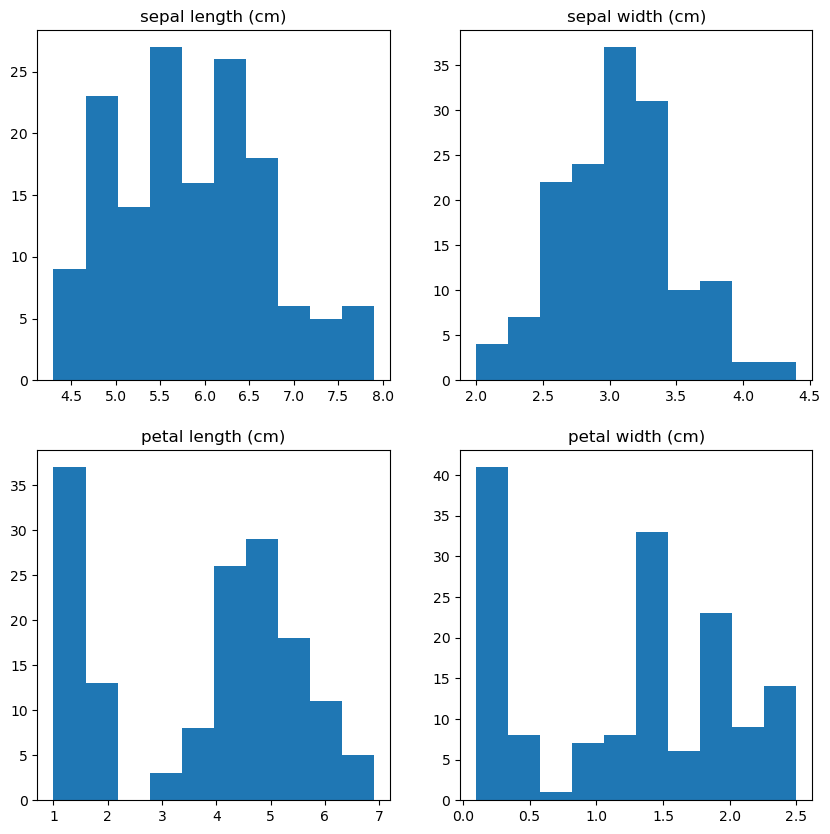

In [5]:
_, ax = plt.subplots(2, 2, figsize=(10, 10))
ax = ax.flatten()
for i in range(4):
    ax[i].hist(data.data[:, i])
    ax[i].set_title(data.feature_names[i])
plt.show()

(5) Wir haben bisher jedes Feature (Eigenschaft) einzeln betrachtet. Lassen Sie uns nun Paare von unterschiedlichen Features betrachten.
  * Wie viele solcher Featurepaare gibt es?
  * Erzeugen Sie für jedes dieser Featurepaare einen Scatterplot. Nutzen Sie dazu den `scatter` Befehl ([Dokumentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html)).
  * Falls Sie dies noch nicht gemacht haben: Modifizieren Sie die Scatterplots so, dass die Farben der Punkte die Schwertlilienart kodiert (benutzen Sie dazu die Informationen "target" im Datensatz und verknüpfen diese mit dem `c=` Argument des scatter Befehls ([Dokumentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html))).
  * Gibt es in den Scatterplots auffällige Muster? Haben Sie eine Idee, ob und wie sich manche Schwertlilienarten von anderen unterscheiden lassen?

Es gibt 6 Featurepaare, die jeweils in der oberen bzw gespiegelt in der unteren Dreiecksmatrix zu sehen sind


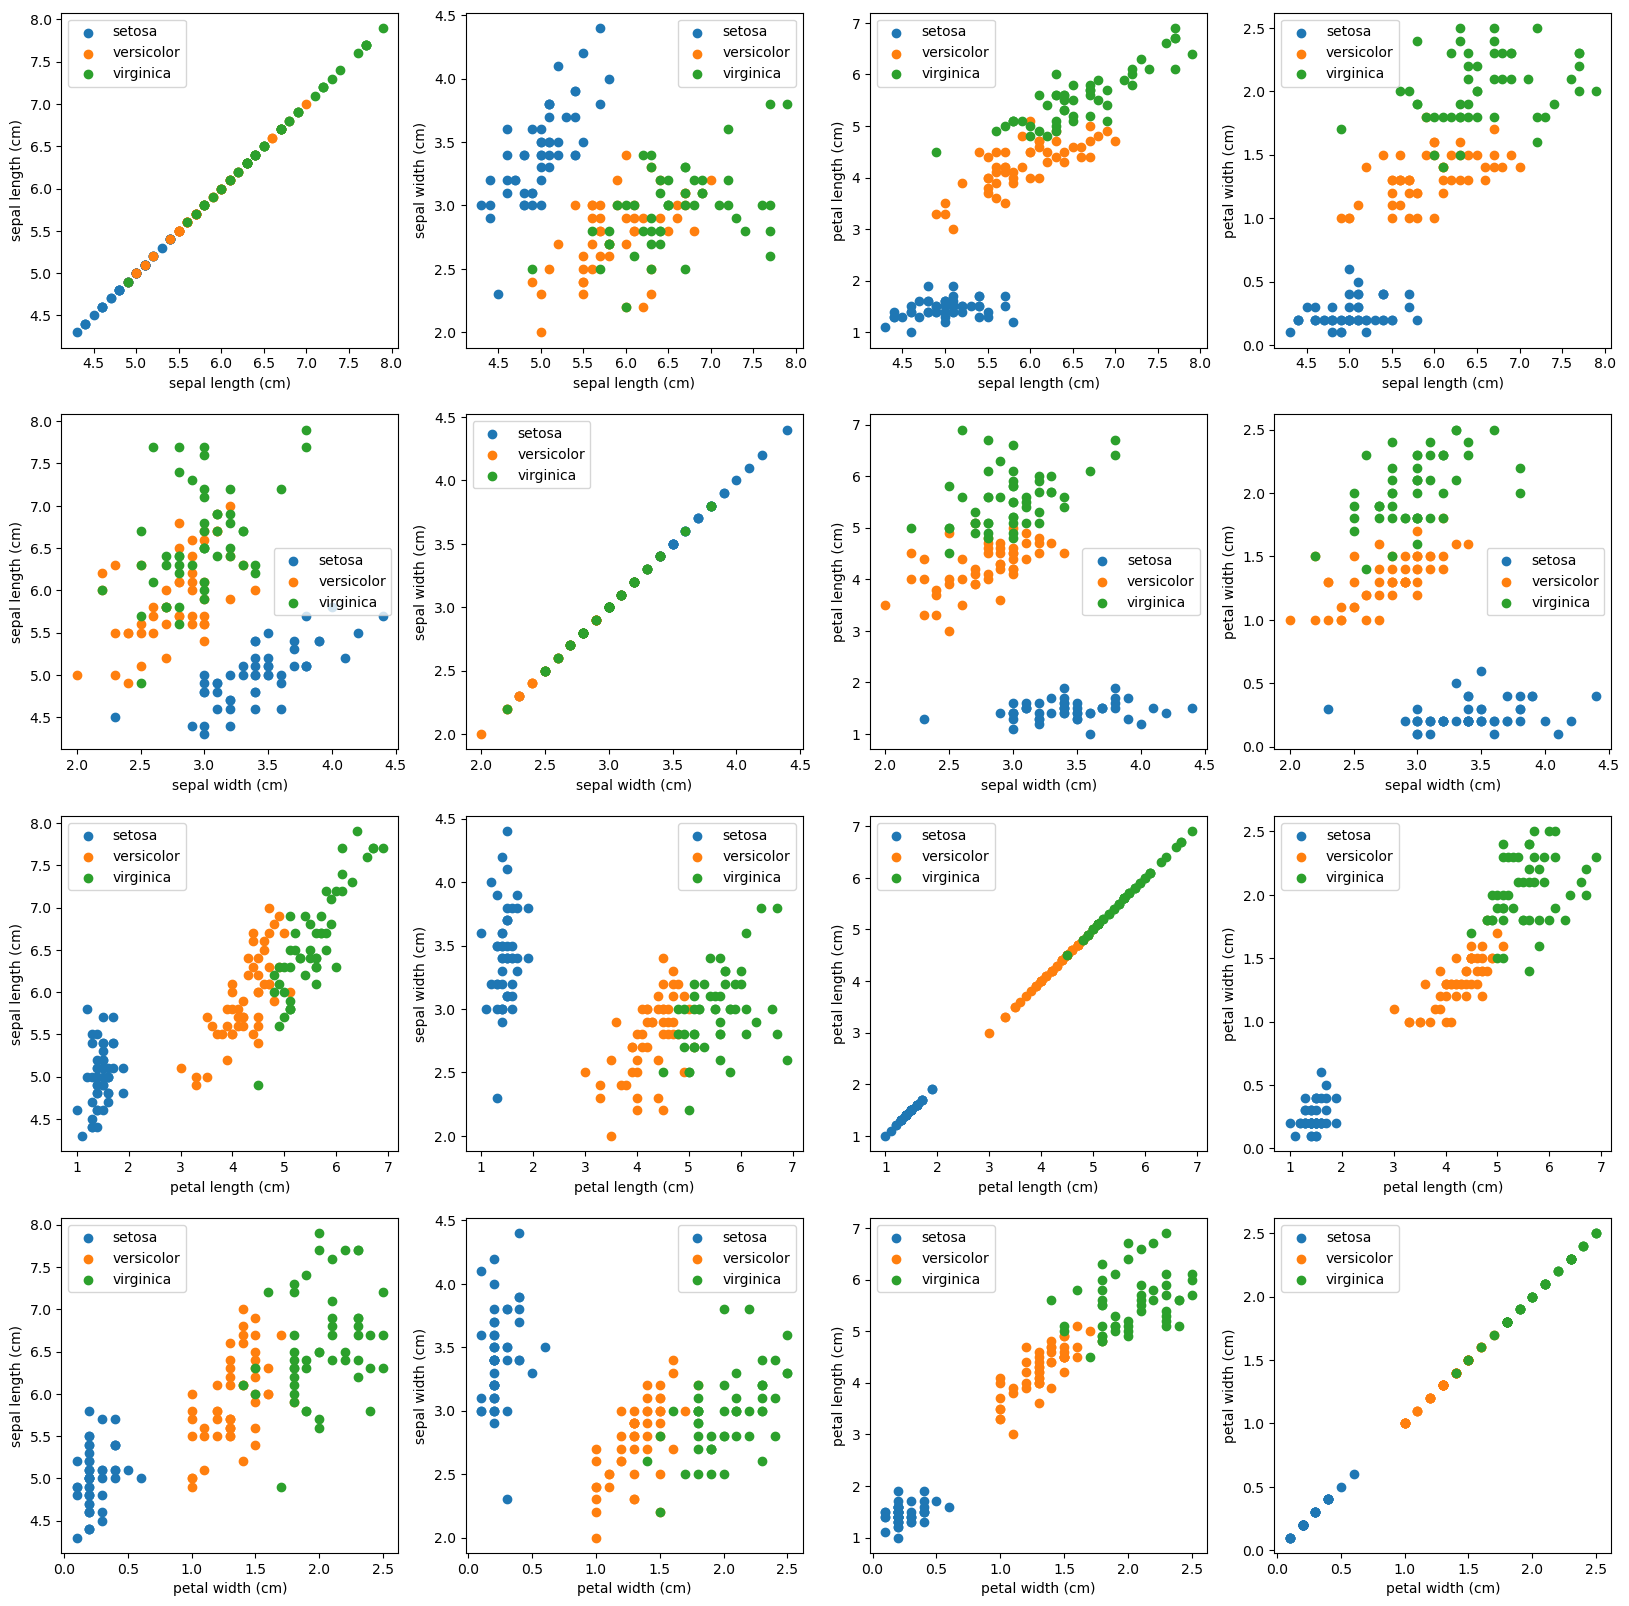

In [6]:
print('Es gibt 6 Featurepaare, die jeweils in der oberen bzw gespiegelt in der unteren Dreiecksmatrix zu sehen sind')
_, ax = plt.subplots(4, 4, figsize=(20, 20))
for i, feat1 in enumerate(data.feature_names):
    for j, feat2 in enumerate(data.feature_names):
        for target in np.unique(data.target):
            ax[i, j].scatter(data.data[:, i][target == data.target], data.data[:, j][target == data.target], label=data.target_names[target])
        ax[i, j].set_xlabel(feat1)
        ax[i, j].set_ylabel(feat2)
        ax[i, j].legend()
plt.show()

# 1.3 \[Optional\] Synthetischer Datensatz

Dieser Übungsteil ist für diejenigen unter Ihnen bestimmt, die nicht die Tutorials durcharbeiten mussten und sich schon in Python auskennen. Wir werden einen synthetischen Datensatz erzeugen, den wir in einer der kommenden Übungen nutzen wollen.

Implementieren Sie eine Funktion, die eine Anzahl von `N` Punkten in einer 2-dimensionalen Ebene erzeugt. Die x- und y-Koordinaten der Punkte seien zufällig gewählt und müssen im Interval \[0,1\] liegen. Jeder Punkt gehört entweder der Klasse "-1" oder "+1" an. *Beide Klassen seien durch eine zufällige Gerade voneinander getrennt.* 

* Die Funktion nimmt die gewünschte Anzahl Punkte `N` (integer) entgegen.
* Die Funktion gibt ein numpy array der Dimension (N, 2) aus, wobei jede Zeile des Arrays die x- und y-Koordinaten des i-ten Punktes enthält (das sind die Features). Daneben gibt die Funktion ein zweites numpy array der Dimension (N,) aus, das für jeden Punkt `i` den Integer "-1" oder "+1" je nach Klassenzugehörigkeit enthält (das sind die labels). 


Visualisieren Sie einen beispielhaften Datensatz in einem Scatterplot.

*Implementierungshinweis:* Sie können, wenn Sie wollen, zufällige Punktkoordinaten für `N` Punkte erzeugen und dann eine zufällige Gerade in die Ebene legen. Ermitteln Sie anschließend die Punkte, die über der Gerade liegen (das sind Punkte der einen Klasse) und dann die Punkte, die unter der Geraden liegen (das sind die Punkte der anderen Klasse). Nutzen Sie diese Informationen, um die Klassenzugehörigkeit in einem zweiten numpy array zurückzugeben.

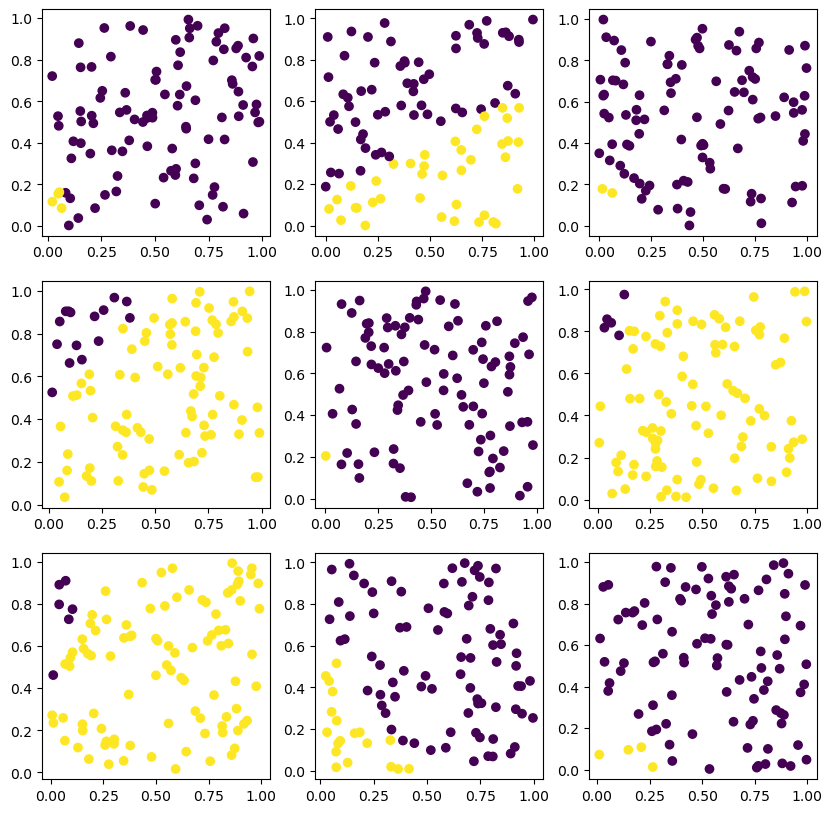

In [7]:
def generate_data(n: int) -> tuple[np.ndarray[np.float64], np.ndarray[np.int32]]:
    coords = np.random.random((n, 2))
    b = np.random.random(1)
    a = np.random.randn() * 2
    labels = [-1 if b + coord[0] * a < coord[1] else 0 for coord in coords]
    return coords, labels

_, ax = plt.subplots(3, 3, figsize=(10, 10))
ax = ax.flatten()
for i in range(9):
    coords, labels = generate_data(100)
    ax[i].scatter(coords[:, 0], coords[:, 1], c=labels)
plt.show()